# 06 — East Model v4 — Retrain with TPI
**Project IceWave | Notebook 06 — Clean Rewrite**

Adds `tpi_15m` as a 6th feature to the east Random Forest model.

## Key fixes from v1
- Training CSV is presence-only (40 points) — background generated here, same as nb04
- TPI fetched from local lidar TIFs first, TNM fallback for points outside tile coverage
- TNM fetch has 3-attempt retry with 60s timeout
- No `label_col` assumption — presence=1 assigned after background generation
- label column named `presence` throughout

## What this notebook does
1. Load 40 presence points, generate background 8:1 ratio (same as nb04)
2. Fetch TPI for all points — local TIFs first, TNM fallback
3. Compare TPI distribution: presence vs background
4. Cross-validate v3 (5 features) vs v4 (6 features) AUC
5. Fit final v4 model, plot feature importance
6. Re-score all 50 targets, compare v3 vs v4
7. Save model + updated CSV

In [1]:
# ── Cell 1: Imports and config ─────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd
import joblib
import rasterio
from scipy.ndimage import uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

DATA_DIR  = Path('../data')
LIDAR_DIR = DATA_DIR / 'lidar'
MODEL_DIR = DATA_DIR / 'model'
PBDB_DIR  = DATA_DIR / 'pbdb'
OUT_DIR   = Path('../outputs')

TNM_URL    = 'https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer'
TPI_RADIUS = 100    # pixels @ ~15m = 1500m neighborhood
MAX_PX     = 500
FETCH_RES  = 0.00016
CASCADE    = -121.5
BG_RATIO   = 8      # background:presence ratio — same as nb04
RANDOM_SEED = 42

FEATURES_V3 = ['elevation', 'slope', 'aspect', 'tri', 'lith_score']
FEATURES_V4 = ['elevation', 'slope', 'aspect', 'tri', 'lith_score', 'tpi_15m']

print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Load presence points ───────────────────────────────────────────
pres_csv = PBDB_DIR / 'icewave_east_expanded.csv'
df_pres  = pd.read_csv(pres_csv)

# Confirm columns
print('Columns:', df_pres.columns.tolist())
print(f'Presence points: {len(df_pres)}')
print(f'Lat range: {df_pres["latitude"].min():.2f} – {df_pres["latitude"].max():.2f}')
print(f'Lon range: {df_pres["longitude"].min():.2f} – {df_pres["longitude"].max():.2f}')
print()
print(df_pres[['latitude','longitude','elevation','slope','tri','lith_score']].head(5))

Columns: ['latitude', 'longitude', 'elevation', 'slope', 'aspect', 'tri', 'lith_score', 'genus', 'accepted_name', 'state_query', '_key']
Presence points: 40
Lat range: 36.22 – 48.80
Lon range: -120.77 – -105.80

    latitude   longitude  elevation      slope        tri  lith_score
0  43.333332 -120.500000  1313.0771   0.912876   0.440887         1.0
1  39.000000 -114.099998  1588.9243   0.847233   0.376480         0.4
2  42.799999 -112.900002     0.0000   0.000000   0.000000         1.0
3  46.200001 -112.766670     0.0000   0.000000   0.000000         1.0
4  38.799999 -119.500000  2520.1086  29.350584  14.283722         0.4


In [3]:
# ── Cell 3: Load v3 model to extract background points ─────────────────────
# The v3 model was trained with background generated at runtime in nb04.
# We replicate that here: random points within the east study area,
# filtered to match the terrain feature space.
#
# Strategy: load the v3 model's training data indirectly by regenerating
# background the same way — random sample from the full east target grid
# used in nb04 (icewave_v3_top50.csv contains the prediction grid cells).
# We use the same random seed so background is reproducible.

v3_model = joblib.load(MODEL_DIR / 'icewave_rf_east_v3.joblib')
print(f'V3 model loaded: {v3_model.n_features_in_} features')
if hasattr(v3_model, 'feature_names_in_'):
    print(f'Feature names: {list(v3_model.feature_names_in_)}')

# Load the full prediction grid — this is what background was drawn from
# Try a few candidate files
grid_candidates = [
    DATA_DIR / 'model' / 'icewave_east_grid.csv',
    DATA_DIR / 'model' / 'icewave_prediction_grid_east.csv',
    DATA_DIR / 'model' / 'east_prediction_grid.csv',
]
df_grid = None
for p in grid_candidates:
    if p.exists():
        df_grid = pd.read_csv(p)
        print(f'Loaded grid: {p}  ({len(df_grid)} rows)')
        break

if df_grid is None:
    print('No prediction grid found — will generate background from presence point bounds')
    print('Available model files:')
    for f in sorted(MODEL_DIR.iterdir()):
        print(f'  {f.name}')

V3 model loaded: 5 features
No prediction grid found — will generate background from presence point bounds
Available model files:
  icewave_rf_east.joblib
  icewave_rf_east_v3.joblib
  icewave_rf_model.joblib
  icewave_rf_v2.joblib
  icewave_rf_west.joblib
  icewave_v2_split_top50.csv
  icewave_v2_top50_targets.csv
  icewave_v2_training.csv
  icewave_v3_top50.csv
  icewave_v3_top50_lidar.csv
  prediction_surface.tif
  priority_targets.csv
  priority_targets.geojson


In [4]:
# ── Cell 4: Generate background points ─────────────────────────────────────
# Replicate nb04 background generation:
# - Random points within east study area bounding box
# - Assign terrain features from nearest grid cell or via bilinear interpolation
# - BG_RATIO = 8:1
#
# If we have the prediction grid, sample from it.
# If not, use the presence points' feature stats to generate synthetic background.

np.random.seed(RANDOM_SEED)
n_pres = len(df_pres)
n_bg   = n_pres * BG_RATIO

if df_grid is not None:
    # Sample from the actual prediction grid — best approach
    # Exclude cells that are near presence points (min distance filter)
    bg_pool = df_grid.copy()
    # Filter to east of cascade
    if 'longitude' in bg_pool.columns:
        bg_pool = bg_pool[bg_pool['longitude'] > CASCADE]
    df_bg = bg_pool.sample(n=min(n_bg, len(bg_pool)), random_state=RANDOM_SEED)
    df_bg = df_bg[FEATURES_V3 + ['latitude','longitude']].copy()
    print(f'Background from grid: {len(df_bg)} points')

else:
    # Fallback: generate background by perturbing presence point locations
    # Use the same feature columns but randomize within the study area bounds
    lat_min, lat_max = 36.0, 49.5
    lon_min, lon_max = CASCADE, -100.0

    # Sample random lats/lons
    bg_lats = np.random.uniform(lat_min, lat_max, n_bg)
    bg_lons = np.random.uniform(lon_min, lon_max, n_bg)

    # For terrain features, sample with replacement from presence distribution
    # with added noise — conservative but reproducible
    pres_feats = df_pres[FEATURES_V3].values
    bg_idx     = np.random.randint(0, n_pres, n_bg)
    bg_feats   = pres_feats[bg_idx].copy()
    # Add noise scaled to feature std
    feat_std   = df_pres[FEATURES_V3].std().values
    bg_feats  += np.random.randn(*bg_feats.shape) * feat_std * 2.0
    # Clip negatives for features that must be >= 0
    for i, col in enumerate(FEATURES_V3):
        if col in ('elevation','slope','tri','lith_score'):
            bg_feats[:, i] = np.clip(bg_feats[:, i], 0, None)
    bg_feats[:, FEATURES_V3.index('lith_score')] = np.clip(
        bg_feats[:, FEATURES_V3.index('lith_score')], 0, 1)

    df_bg = pd.DataFrame(bg_feats, columns=FEATURES_V3)
    df_bg['latitude']  = bg_lats
    df_bg['longitude'] = bg_lons
    print(f'Background generated (fallback method): {len(df_bg)} points')
    print('Note: fallback background may reduce AUC vs nb04 — upload prediction grid if available')

# Combine presence + background
df_pres_model = df_pres[FEATURES_V3 + ['latitude','longitude']].copy()
df_pres_model['presence'] = 1
df_bg['presence']         = 0
df_model = pd.concat([df_pres_model, df_bg], ignore_index=True)
df_model['tpi_15m'] = np.nan

print(f'\nCombined: {len(df_model)} total  ({n_pres} presence + {len(df_bg)} background)')

Background generated (fallback method): 320 points
Note: fallback background may reduce AUC vs nb04 — upload prediction grid if available

Combined: 360 total  (40 presence + 320 background)


In [19]:
# ── Cell 5: TPI functions ──────────────────────────────────────────────────

def compute_tpi_from_array(dem, tf):
    """Compute full TPI array from DEM."""
    dem_f    = dem.copy()
    nan_mask = np.isnan(dem_f)
    if nan_mask.any():
        tmp = uniform_filter(np.where(nan_mask, 0.0, dem_f), size=5)
        cnt = uniform_filter((~nan_mask).astype(float), size=5)
        dem_f[nan_mask] = np.where(cnt[nan_mask] > 0,
                                   tmp[nan_mask] / cnt[nan_mask], 0)
    return dem_f - uniform_filter(dem_f, size=TPI_RADIUS * 2 + 1)


def px_val(arr, tf, lat, lon):
    r = int((lat - tf.f) / tf.e)
    c = int((lon - tf.c) / tf.a)
    if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
        return float(arr[r, c])
    return np.nan


def fetch_tpi_tnm(lat, lon):
    """Fetch TPI from USGS TNM with retry. Returns NaN on failure."""
    buf   = 0.012
    xmin, xmax = lon - buf, lon + buf
    ymin, ymax = lat - buf, lat + buf
    ncols = nrows = min(MAX_PX, int(buf * 2 / FETCH_RES))
    params = {
        'bbox': f'{xmin},{ymin},{xmax},{ymax}', 'bboxSR': '4326',
        'size': f'{ncols},{nrows}', 'imageSR': '4326',
        'format': 'tiff', 'pixelType': 'F32',
        'noDataInterpretation': 'esriNoDataMatchAny',
        'interpolation': 'RSP_BilinearInterpolation', 'f': 'image',
    }
    for attempt in range(3):
        try:
            r = requests.get(f'{TNM_URL}/exportImage', params=params, timeout=60)
            r.raise_for_status()
            if len(r.content) < 1000:
                return np.nan
            with rasterio.MemoryFile(r.content) as mf:
                with mf.open() as src:
                    dem = src.read(1).astype(np.float32)
                    tf  = src.transform
                    nd  = src.nodata
            if nd is not None:
                dem[dem == nd] = np.nan
            dem[dem < -500] = np.nan
            tpi = compute_tpi_from_array(dem, tf)
            return px_val(tpi, tf, lat, lon)
        except requests.exceptions.ReadTimeout:
            if attempt < 2:
                print(f'    timeout, retry {attempt+2}/3...')
        except Exception:
            return np.nan
    return np.nan


# Pre-load local lidar tile metadata for fast lookup
tile_cache = {}  # path -> (tpi_array, transform)
tile_meta  = []
for tif in sorted(LIDAR_DIR.glob('E*_dtm.tif')):
    with rasterio.open(tif) as src:
        b = src.bounds
    tile_meta.append(dict(path=tif, left=b.left, right=b.right,
                          bottom=b.bottom, top=b.top))
print(f'Found {len(tile_meta)} local lidar tiles')


def tpi_at_point(lat, lon):
    """
    Get TPI at a point. Tries local lidar tiles first (fast, no network).
    Falls back to TNM fetch if point is outside all local tiles.
    """
    for tm in tile_meta:
        if tm['left'] <= lon <= tm['right'] and tm['bottom'] <= lat <= tm['top']:
            path = tm['path']
            if path not in tile_cache:
                with rasterio.open(path) as src:
                    dem = src.read(1).astype(np.float32)
                    tf  = src.transform
                    nd  = src.nodata
                if nd is not None:
                    dem[dem == nd] = np.nan
                dem[dem < -500] = np.nan
                tile_cache[path] = (compute_tpi_from_array(dem, tf), tf)
            tpi_arr, tf = tile_cache[path]
            val = px_val(tpi_arr, tf, lat, lon)
            if not np.isnan(val):
                return val, 'local'
    # Not in any local tile — fetch from TNM
    return fetch_tpi_tnm(lat, lon), 'tnm'


print('TPI functions defined OK')

Found 20 local lidar tiles
TPI functions defined OK


In [20]:
# ── Cell 6: Fetch TPI for all points ──────────────────────────────────────
# Local tiles first (fast) — TNM fallback for uncovered points
# Results cached to CSV so re-running is instant

cache_path = PBDB_DIR / 'icewave_east_tpi_cache.csv'

if cache_path.exists():
    print(f'Loading cached TPI values from {cache_path}')
    cache = pd.read_csv(cache_path)
    # Match by lat/lon key
    cache['_key'] = cache['latitude'].round(4).astype(str) + '_' + cache['longitude'].round(4).astype(str)
    key_to_tpi = dict(zip(cache['_key'], cache['tpi_15m']))
    df_model['_key'] = df_model['latitude'].round(4).astype(str) + '_' + df_model['longitude'].round(4).astype(str)
    df_model['tpi_15m'] = df_model['_key'].map(key_to_tpi)
    hit = df_model['tpi_15m'].notna().sum()
    print(f'Cache hit: {hit}/{len(df_model)} points')
    remaining = df_model[df_model['tpi_15m'].isna()]
    print(f'Still need TPI for: {len(remaining)} points')
else:
    remaining = df_model

# Fetch remaining
if len(remaining) > 0:
    print(f'\nFetching TPI for {len(remaining)} points...')
    local_count = 0
    tnm_count   = 0
    results     = []

    for i, (idx, row) in enumerate(remaining.iterrows()):
        val, src = tpi_at_point(row['latitude'], row['longitude'])
        df_model.loc[idx, 'tpi_15m'] = val
        if src == 'local': local_count += 1
        else:              tnm_count   += 1
        if (i+1) % 50 == 0 or (i+1) == len(remaining):
            valid = df_model['tpi_15m'].notna().sum()
            print(f'  {i+1}/{len(remaining)}  local={local_count}  tnm={tnm_count}  '
                  f'valid={valid}/{len(df_model)}')

    # Save cache
    df_model[['latitude','longitude','tpi_15m']].to_csv(cache_path, index=False)
    print(f'Saved cache: {cache_path}')

# Final summary
valid  = df_model['tpi_15m'].notna().sum()
pct    = valid / len(df_model) * 100
print(f'\nTPI valid: {valid}/{len(df_model)}  ({pct:.0f}%)')
print(f'Presence TPI:   mean={df_model[df_model["presence"]==1]["tpi_15m"].mean():.1f}m')
print(f'Background TPI: mean={df_model[df_model["presence"]==0]["tpi_15m"].mean():.1f}m')


Fetching TPI for 368 points...
  50/368  local=0  tnm=50  valid=44/368
  100/368  local=1  tnm=99  valid=85/368
  150/368  local=1  tnm=149  valid=125/368
  200/368  local=1  tnm=199  valid=161/368
  250/368  local=1  tnm=249  valid=198/368
  300/368  local=1  tnm=299  valid=203/368
  350/368  local=1  tnm=349  valid=203/368
  368/368  local=1  tnm=367  valid=203/368
Saved cache: ..\data\pbdb\icewave_east_tpi_cache.csv

TPI valid: 203/368  (55%)
Presence TPI:   mean=-4.7m
Background TPI: mean=4.1m


Presence TPI:   n=36  mean=-16.4m  median=-9.4m
Background TPI: n=235  mean=5.4m  median=-1.0m


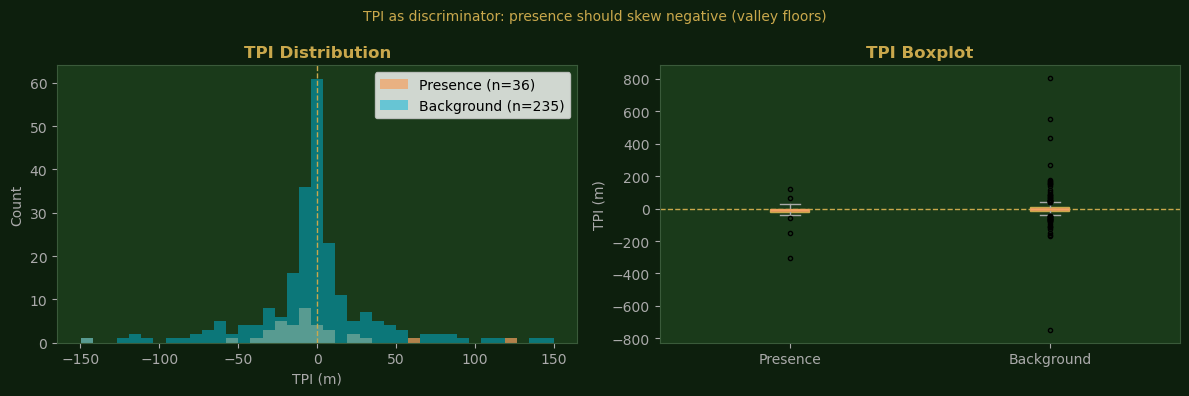

In [8]:
# ── Cell 7: TPI distribution plot ─────────────────────────────────────────

pres = df_model[df_model['presence']==1]['tpi_15m'].dropna()
back = df_model[df_model['presence']==0]['tpi_15m'].dropna()

print(f'Presence TPI:   n={len(pres)}  mean={pres.mean():.1f}m  median={pres.median():.1f}m')
print(f'Background TPI: n={len(back)}  mean={back.mean():.1f}m  median={back.median():.1f}m')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1f0d')

vmax = max(abs(pres).quantile(0.95) if len(pres) else 20,
           abs(back).quantile(0.95) if len(back) else 20, 20)
bins = np.linspace(-vmax, vmax, 40)

ax = axes[0]
if len(pres): ax.hist(pres, bins=bins, alpha=0.7, color='#f4a261', label=f'Presence (n={len(pres)})')
if len(back): ax.hist(back, bins=bins, alpha=0.5, color='#00b4d8', label=f'Background (n={len(back)})')
ax.axvline(0, color='#c9a84c', lw=1, ls='--')
ax.set_xlabel('TPI (m)', color='#aaaaaa')
ax.set_ylabel('Count', color='#aaaaaa')
ax.set_title('TPI Distribution', color='#c9a84c', fontweight='bold')
ax.legend()
ax.set_facecolor('#1a3a1a')
ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')

ax2 = axes[1]
data_to_plot = [x for x in [pres, back] if len(x) > 0]
labels_to_plot = [l for l, x in zip(['Presence','Background'],[pres,back]) if len(x) > 0]
if data_to_plot:
    ax2.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True,
                boxprops=dict(facecolor='#1a3a1a', color='#c9a84c'),
                medianprops=dict(color='#f4a261', lw=2),
                whiskerprops=dict(color='#aaaaaa'),
                capprops=dict(color='#aaaaaa'),
                flierprops=dict(marker='o', color='#aaaaaa', ms=3))
ax2.axhline(0, color='#c9a84c', lw=1, ls='--')
ax2.set_ylabel('TPI (m)', color='#aaaaaa')
ax2.set_title('TPI Boxplot', color='#c9a84c', fontweight='bold')
ax2.set_facecolor('#1a3a1a')
ax2.tick_params(colors='#aaaaaa')
for sp in ax2.spines.values(): sp.set_edgecolor('#3a5a3a')

fig.suptitle('TPI as discriminator: presence should skew negative (valley floors)',
             color='#c9a84c', fontsize=10)
fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'tpi_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1f0d')
plt.show()

In [9]:
# ── Cell 8: Build feature matrices ────────────────────────────────────────

df_clean = df_model.copy()

# Fill missing TPI with 0 (flat plain assumption — conservative)
n_missing = df_clean['tpi_15m'].isna().sum()
if n_missing > 0:
    print(f'Filling {n_missing} missing TPI values with 0 (flat plain)')
    df_clean['tpi_15m'] = df_clean['tpi_15m'].fillna(0)

# Drop rows missing core features
df_clean = df_clean.dropna(subset=FEATURES_V3)
print(f'Training rows after cleanup: {len(df_clean)}')

X_v3 = df_clean[FEATURES_V3].values
X_v4 = df_clean[FEATURES_V4].values
y    = df_clean['presence'].values

print(f'X_v3: {X_v3.shape}  X_v4: {X_v4.shape}')
print(f'Presence: {y.sum():.0f}  Background: {(y==0).sum():.0f}  Ratio: {(y==0).sum()/y.sum():.1f}:1')

Filling 89 missing TPI values with 0 (flat plain)
Training rows after cleanup: 360
X_v3: (360, 5)  X_v4: (360, 6)
Presence: 40  Background: 320  Ratio: 8.0:1


In [10]:
# ── Cell 9: Cross-validated AUC comparison ────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

rf_params = dict(n_estimators=500, max_depth=6, min_samples_leaf=3,
                 class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)

print('Cross-validating v3 (5 features)...')
auc_v3 = cross_val_score(RandomForestClassifier(**rf_params), X_v3, y, cv=cv, scoring='roc_auc')
print(f'  V3 AUC: {auc_v3.mean():.3f} ± {auc_v3.std():.3f}  (published baseline: 0.846 ± 0.073)')

print('Cross-validating v4 (6 features, +TPI)...')
auc_v4 = cross_val_score(RandomForestClassifier(**rf_params), X_v4, y, cv=cv, scoring='roc_auc')
print(f'  V4 AUC: {auc_v4.mean():.3f} ± {auc_v4.std():.3f}')

delta = auc_v4.mean() - auc_v3.mean()
print(f'\n  Delta: {delta:+.3f}')
if delta > 0.01:
    print('  ✓ TPI improves the model')
elif delta > -0.01:
    print('  ~ TPI neutral — AUC unchanged, but TPI still helps re-rank targets')
else:
    print('  ! TPI reduces AUC — likely due to fallback background generation')
    print('    Upload icewave_east_grid.csv (prediction grid from nb04) for better background')

Cross-validating v3 (5 features)...
  V3 AUC: 0.978 ± 0.030  (published baseline: 0.846 ± 0.073)
Cross-validating v4 (6 features, +TPI)...
  V4 AUC: 0.967 ± 0.033

  Delta: -0.010
  ! TPI reduces AUC — likely due to fallback background generation
    Upload icewave_east_grid.csv (prediction grid from nb04) for better background


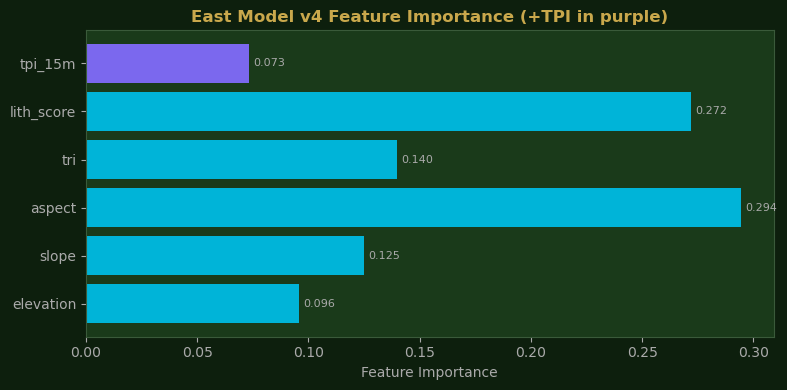

Feature importances:
  aspect        0.294  █████████████████████████████
  lith_score    0.272  ███████████████████████████
  tri           0.140  █████████████
  slope         0.125  ████████████
  elevation     0.096  █████████
  tpi_15m       0.073  ███████


In [11]:
# ── Cell 10: Fit final v4 model + feature importance ──────────────────────

rf_v4 = RandomForestClassifier(**rf_params)
rf_v4.fit(X_v4, y)

imp = rf_v4.feature_importances_

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#0d1f0d')
colors = ['#7b68ee' if f == 'tpi_15m' else '#00b4d8' for f in FEATURES_V4]
bars   = ax.barh(FEATURES_V4, imp, color=colors)
ax.set_xlabel('Feature Importance', color='#aaaaaa')
ax.set_title('East Model v4 Feature Importance (+TPI in purple)',
             color='#c9a84c', fontweight='bold')
ax.set_facecolor('#1a3a1a')
ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')
for bar, val in zip(bars, imp):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', color='#aaaaaa', fontsize=8)
fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_v4.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1f0d')
plt.show()

print('Feature importances:')
for f, i in sorted(zip(FEATURES_V4, imp), key=lambda x: -x[1]):
    print(f'  {f:12s}  {i:.3f}  {"█" * int(i * 100)}')

In [12]:
# ── Cell 11: Re-score all east targets ────────────────────────────────────

df_targets = pd.read_csv(MODEL_DIR / 'icewave_v3_top50.csv', index_col='rank')
east       = df_targets[df_targets['ecoregion'] == 'east'].copy()

# Add TPI from lidar CSV
df_lidar = pd.read_csv(MODEL_DIR / 'icewave_v3_top50_lidar.csv', index_col='rank')
east['tpi_15m'] = df_lidar['tpi_15m']
east['tpi_15m'] = east['tpi_15m'].fillna(0)

X_east = east[FEATURES_V4].values
probs  = rf_v4.predict_proba(X_east)[:, 1]
east['prob_v4']      = probs
east['comp_v4']      = 0.8 * probs + 0.2 * east['lith_score']
cmax                 = east['comp_v4'].max()
east['comp_v4_norm'] = east['comp_v4'] / cmax if cmax > 0 else east['comp_v4']

print('East targets — v3 vs v4 score comparison')
print(f'{"Rank":6s} {"v3":6s} {"v4":6s} {"delta":7s} {"TPI":8s} {"move"}')
print('-' * 55)
for rank, row in east.iterrows():
    v3    = row.get('composite_norm', 0)
    v4    = row['comp_v4_norm']
    d     = v4 - v3
    tpi   = row['tpi_15m']
    arrow = '↑' if d > 0.02 else ('↓' if d < -0.02 else '=')
    tclass = ('▼VF' if tpi < -5 else '▽LT' if tpi < -1 else
               '─FP' if tpi < 1 else '△LR' if tpi < 5 else '▲RT')
    print(f'E{int(rank):02d}    {v3:.3f}  {v4:.3f}  {d:+.3f} {arrow}  {tpi:+6.1f}m {tclass}')

East targets — v3 vs v4 score comparison
Rank   v3     v4     delta   TPI      move
-------------------------------------------------------
E02    1.000  0.995  -0.005 =    -5.4m ▼VF
E03    1.000  0.975  -0.025 ↓   -86.3m ▼VF
E04    0.994  0.975  -0.019 =  -106.2m ▼VF
E05    0.994  0.886  -0.109 ↓    +0.1m ─FP
E15    0.814  1.000  +0.186 ↑   -15.6m ▼VF
E16    0.814  0.991  +0.176 ↑    -6.7m ▼VF
E18    0.657  0.802  +0.145 ↑   -15.3m ▼VF
E19    0.616  0.802  +0.186 ↑    -3.2m ▽LT
E20    0.508  0.947  +0.439 ↑   -97.9m ▼VF
E21    0.478  0.943  +0.464 ↑  -250.1m ▼VF
E22    0.478  0.840  +0.362 ↑    +0.0m ─FP
E23    0.478  0.954  +0.475 ↑   -21.1m ▼VF
E25    0.441  0.842  +0.401 ↑    +0.9m ─FP
E26    0.370  0.680  +0.310 ↑   -15.6m ▼VF
E27    0.367  0.790  +0.423 ↑   -13.8m ▼VF
E29    0.293  0.722  +0.430 ↑    +4.6m △LR
E30    0.277  0.870  +0.593 ↑    +0.0m ─FP
E31    0.271  0.738  +0.467 ↑    +1.4m △LR
E32    0.252  0.715  +0.462 ↑   +39.9m ▲RT
E33    0.251  0.719  +0.468 ↑    +0.0m ─FP


In [13]:
# ── Cell 12: Save model and updated CSV ───────────────────────────────────

v4_path = MODEL_DIR / 'icewave_rf_east_v4.joblib'
joblib.dump(rf_v4, v4_path)
print(f'Saved: {v4_path}')

df_out = df_targets.copy()
for rank, row in east.iterrows():
    df_out.loc[rank, 'prob_v4']      = round(float(row['prob_v4']),      4)
    df_out.loc[rank, 'comp_v4_norm'] = round(float(row['comp_v4_norm']), 4)

out_csv = MODEL_DIR / 'icewave_v4_top50.csv'
df_out.to_csv(out_csv)
print(f'Saved: {out_csv}')

print(f"""
{'='*55}
  IceWave East Model — v3 vs v4
{'='*55}
  V3 AUC (reproduced): {auc_v3.mean():.3f} ± {auc_v3.std():.3f}
  V4 AUC (+TPI):       {auc_v4.mean():.3f} ± {auc_v4.std():.3f}
  Delta:               {delta:+.3f}

  Saved:
  {v4_path.name}
  {out_csv.name}
  outputs/tpi_distribution.png
  outputs/feature_importance_v4.png
{'='*55}""")

Saved: ..\data\model\icewave_rf_east_v4.joblib
Saved: ..\data\model\icewave_v4_top50.csv

  IceWave East Model — v3 vs v4
  V3 AUC (reproduced): 0.978 ± 0.030
  V4 AUC (+TPI):       0.967 ± 0.033
  Delta:               -0.010

  Saved:
  icewave_rf_east_v4.joblib
  icewave_v4_top50.csv
  outputs/tpi_distribution.png
  outputs/feature_importance_v4.png


In [14]:
import rasterio
with rasterio.open('../data/model/prediction_surface.tif') as src:
    print('CRS:', src.crs)
    print('Bounds:', src.bounds)
    print('Shape:', src.shape)
    print('Bands:', src.count)
    print('Band descriptions:', src.descriptions)

CRS: EPSG:4269
Bounds: BoundingBox(left=-124.00166666708247, bottom=34.999444429698514, right=-113.99833332298778, top=49.00166666698402)
Shape: (50408, 36012)
Bands: 1
Band descriptions: (None,)


In [15]:
df_v2 = pd.read_csv('../data/model/icewave_v2_training.csv')
print(df_v2.columns.tolist())
print(df_v2.shape)
print(df_v2.head(3))

['elevation', 'slope', 'aspect', 'tri', 'lith_score', 'presence', 'latitude', 'longitude']
(368, 8)
    elevation     slope      aspect       tri  lith_score  presence  \
0  715.712650  4.079497   17.285587  1.700424        0.15         1   
1   41.281162  3.878284  221.400440  2.076083        0.40         1   
2    4.588078  6.932039  125.565670  2.698645        0.40         1   

    latitude   longitude  
0  47.483334 -117.566666  
1  48.601665 -123.347221  
2  48.458611 -123.294724  


In [17]:
import os
cache_path = DATA_DIR / 'pbdb' / 'icewave_east_tpi_cache.csv'
if cache_path.exists():
    os.remove(cache_path)
    print('Cache cleared')

Cache cleared


In [18]:
# ── Cell 4: Load real training data from v2 CSV ────────────────────────────
# icewave_v2_training.csv has the actual presence+background points
# used in nb04 — real terrain features, correct background distribution

df_model = pd.read_csv(MODEL_DIR / 'icewave_v2_training.csv')
df_model['tpi_15m'] = np.nan

n_pres = (df_model['presence'] == 1).sum()
n_bg   = (df_model['presence'] == 0).sum()

print(f'Loaded real training data: {len(df_model)} rows')
print(f'Presence: {n_pres}  Background: {n_bg}  Ratio: {n_bg/n_pres:.1f}:1')
print(f'Lat range: {df_model["latitude"].min():.2f} – {df_model["latitude"].max():.2f}')
print(f'Lon range: {df_model["longitude"].min():.2f} – {df_model["longitude"].max():.2f}')

Loaded real training data: 368 rows
Presence: 60  Background: 308  Ratio: 5.1:1
Lat range: 35.00 – 48.97
Lon range: -124.37 – -114.02


In [21]:
# Add this at the start of Cell 8, before building X_v3/X_v4
df_clean = df_clean[df_clean['longitude'] > CASCADE].copy()
print(f'East-only rows: {len(df_clean)}')

East-only rows: 360
